# Distribution Plots with Seaborn

`seaborn` is a plotting library that sits on top of matplotlib and gives us ready-made chart types for exploring data, like histograms, joint plots, and pair plots, without having to build them piece by piece. `matplotlib.pyplot` is the lower-level plotting library seaborn is built on, and we still need it directly for small things like arranging multiple plots next to each other.

**Usecase:** Whenever you want to quickly explore a dataset visually, you start by importing these two so all the plotting functions used later in the notebook are available.

In [1]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Distribution Plot Types

We use distribution plots to visualize the distribution of quantitative data.

Let's discuss some plots that allow us to visualize the distribution of a data set. These plots are:

* distplot/histplot
* jointplot
* pairplot
* rugplot

## Loading the Dataset

`sns.load_dataset('tips')` pulls in one of seaborn's built-in sample datasets and hands it back to us as a pandas DataFrame, which is just a table with rows and columns. Seaborn keeps a few small practice datasets like this so you always have real-looking data to try plots on without hunting for your own file.

**Usecase:** Here it loads restaurant bill data (columns like `total_bill`, `tip`, `sex`, `smoker`, `day`, `time`, `size`) that every plot in the rest of the notebook is built from.

In [3]:
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


Let's explore the dataset structure and check the unique values in some columns.

In [4]:
print("Dataset shape:", df.shape)
print("\nDataset info:")
df.info()

Dataset shape: (244, 7)

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


`.unique()` is a pandas method that looks at a single column and returns each distinct value in it exactly once, in the order it first appears.

**Usecase:** Before using a column to color or group a plot, it's good to check what values it actually holds. Here it confirms that the `size` column (number of people at the table) only contains a small set of whole numbers, which is why it works well later as a category in the pairplot's `hue`.

In [5]:
print("Unique values in 'size' column:", df['size'].unique())
print("Unique values in 'sex' column:", df['sex'].unique())
print("Unique values in 'smoker' column:", df['smoker'].unique())
print("Unique values in 'day' column:", df['day'].unique())
print("Unique values in 'time' column:", df['time'].unique())

Unique values in 'size' column: [2 3 4 1 6 5]
Unique values in 'sex' column: ['Female', 'Male']
Categories (2, str): ['Male', 'Female']
Unique values in 'smoker' column: ['No', 'Yes']
Categories (2, str): ['Yes', 'No']
Unique values in 'day' column: ['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, str): ['Thur', 'Fri', 'Sat', 'Sun']
Unique values in 'time' column: ['Dinner', 'Lunch']
Categories (2, str): ['Lunch', 'Dinner']


## Histogram Plots (histplot)

`plt.subplot(1,2,1)` and `plt.subplot(1,2,2)` split the figure into a grid of 1 row and 2 columns, and pick which of those two spots the next plot should be drawn into. `sns.histplot(data, bins=20, kde=True)` draws a histogram, meaning it groups the numbers into 20 buckets ("bins") and shows how many values fall in each one as bars. `kde=True` adds a smooth curve on top that estimates the overall shape of the distribution without the choppiness of individual bars.

**Usecase:** Placing two histograms side by side lets you compare the shape of `total_bill` and `tip` at the same time, for example noticing that both are lopsided toward lower amounts with a few large outliers.

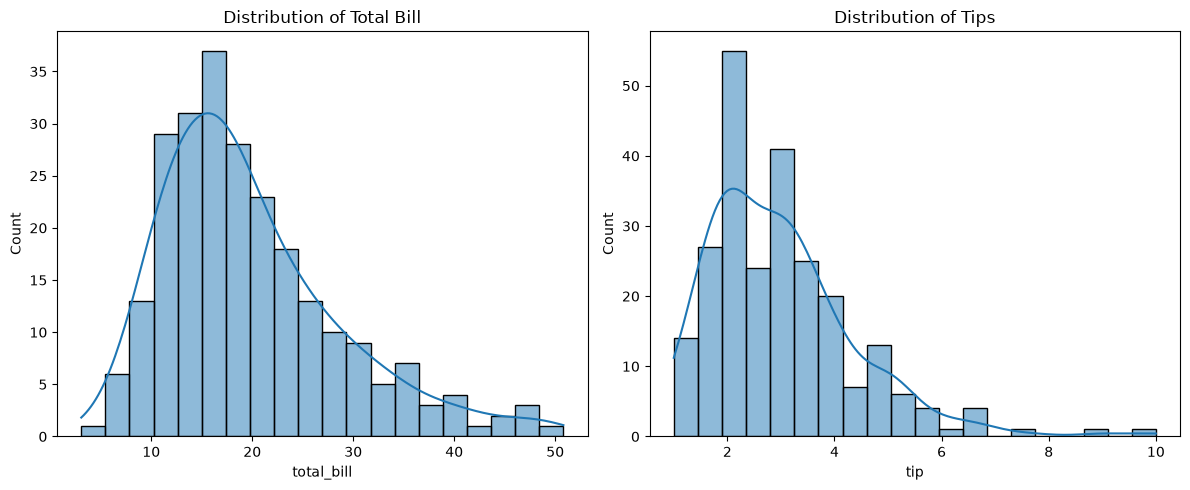

In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['total_bill'], bins=20, kde=True)
plt.title('Distribution of Total Bill')

plt.subplot(1, 2, 2)
sns.histplot(df['tip'], bins=20, kde=True)
plt.title('Distribution of Tips')

plt.tight_layout()
plt.show()

## Joint Plots

`sns.jointplot(x=..., y=..., data=..., kind='scatter')` puts a scatter plot of two columns in the middle (one dot per row of data), and adds a small histogram of each column along the top and right edges. So you get the relationship between the two columns and each column's own shape in one picture.

**Usecase:** Used here to see whether `total_bill` and `tip` move together, for instance whether bigger bills tend to come with bigger tips, while also seeing how each one is distributed on its own.

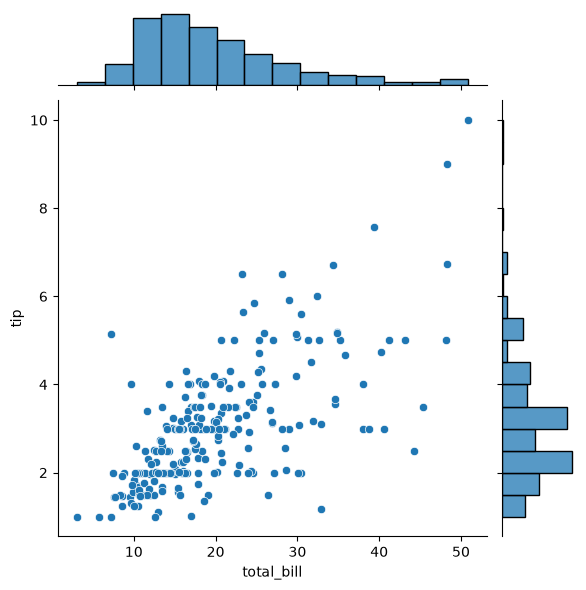

In [7]:
# Scatter joint plot
sns.jointplot(x='total_bill', y='tip', data=df, kind='scatter')
plt.show()

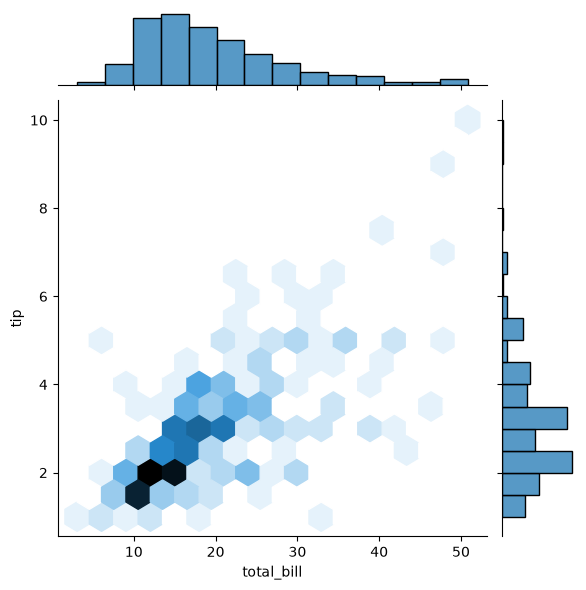

In [8]:
# Hexagonal binning joint plot
sns.jointplot(x='total_bill', y='tip', data=df, kind='hex')
plt.show()

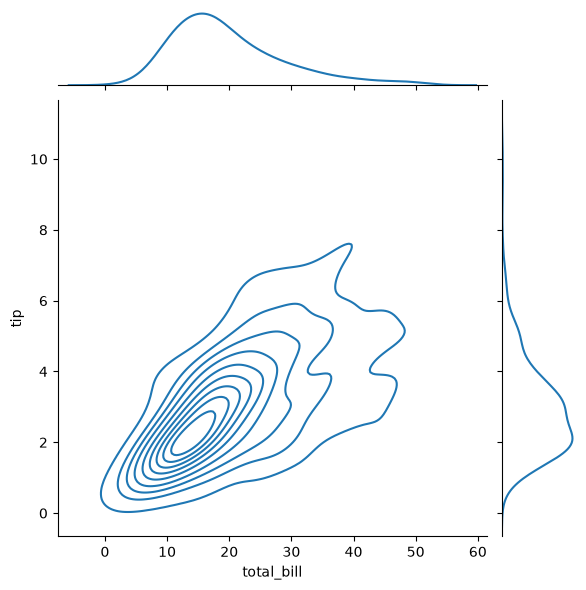

In [9]:
# KDE (Kernel Density Estimation) joint plot
sns.jointplot(x='total_bill', y='tip', data=df, kind='kde')
plt.show()

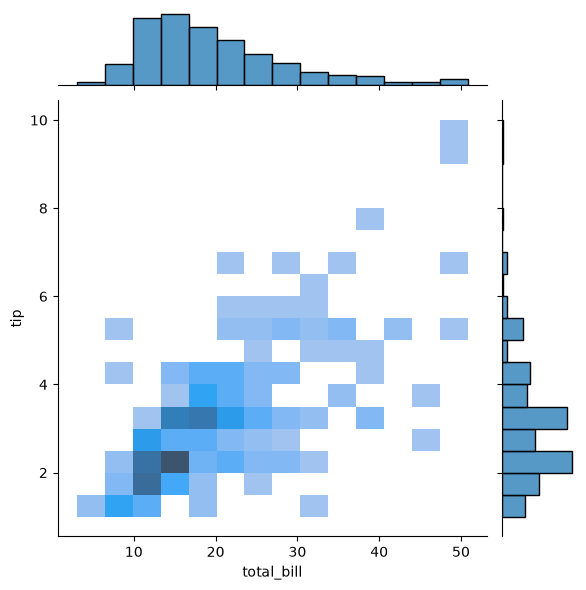

In [10]:
# Histogram joint plot
sns.jointplot(x='total_bill', y='tip', data=df, kind='hist')
plt.show()

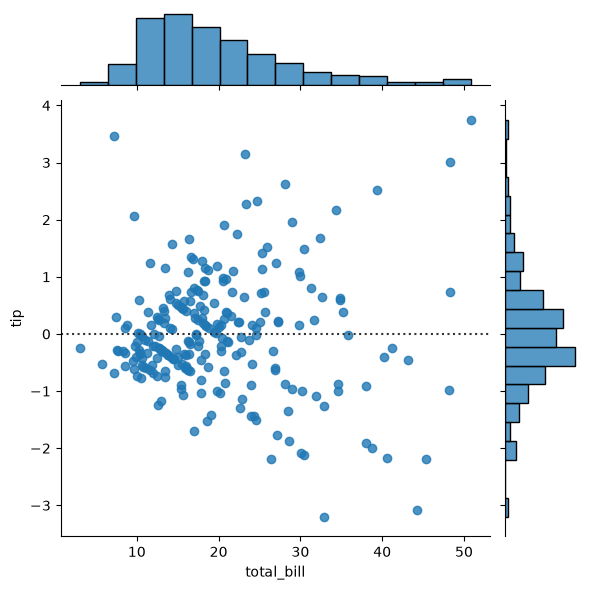

In [11]:
# Residual plot (shows residuals of linear regression)
sns.jointplot(x='total_bill', y='tip', data=df, kind='resid')
plt.show()

### Regression Joint Plot

This is the same `sns.jointplot`, but `kind='reg'` additionally fits a straight line through the scatter points (a simple linear regression) and shades the area of uncertainty around it, on top of everything the scatter kind already shows.

**Usecase:** The straight line makes it easy to answer "as the bill goes up, does the tip generally go up too, and roughly by how much" just by looking at the slope of the line.

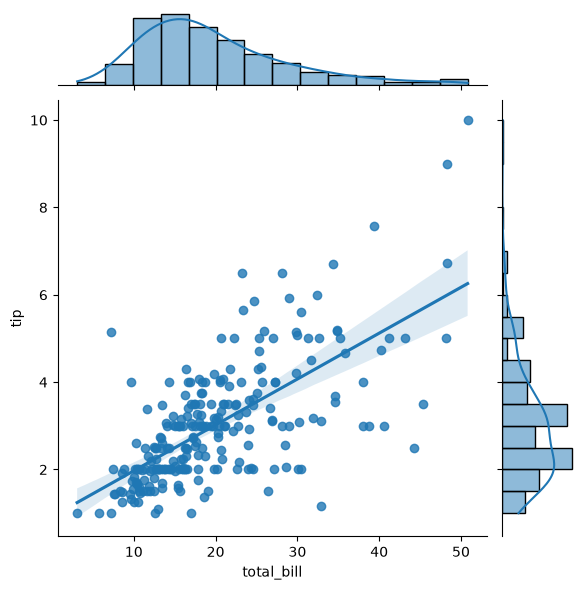

In [12]:
# Regression joint plot
sns.jointplot(x='total_bill', y='tip', data=df, kind='reg')
plt.show()

## Pair Plots

`sns.pairplot(df, hue='size', palette='rainbow')` takes every numeric column in the table and plots each one against every other one, all arranged in a grid automatically. The boxes on the diagonal show each column's own distribution, and the rest show scatter plots between pairs of columns. `hue='size'` colors every point based on the `size` column, and `palette='rainbow'` just picks which set of colors to use for that coloring.

**Usecase:** This is a fast way to eyeball how all the numeric columns relate to each other at once, and here it also shows whether the number of people at the table (`size`) seems to change the pattern between bill amount and tip.

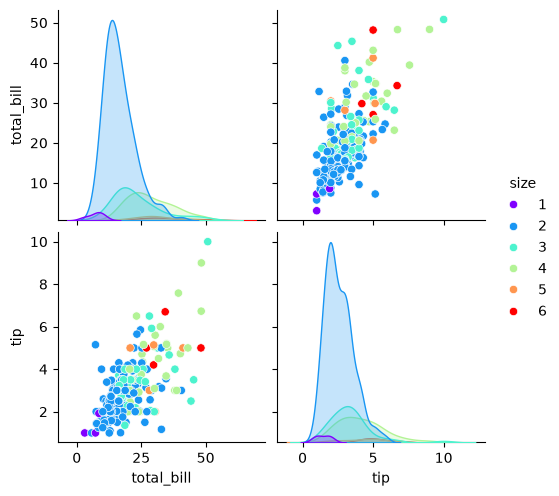

In [13]:
# Pairplot with size as hue and rainbow palette
sns.pairplot(df, hue='size', palette='rainbow')
plt.show()

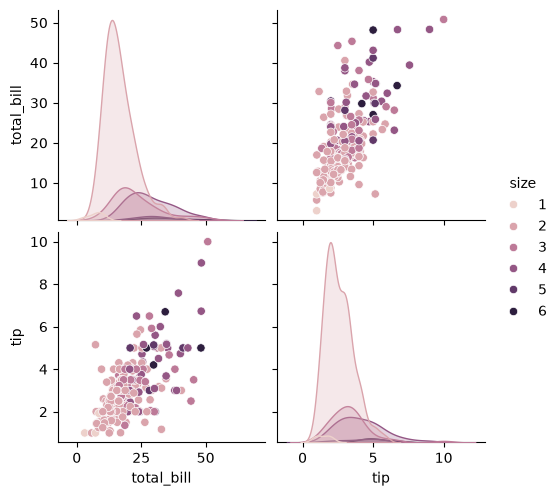

In [14]:
# Pairplot with size as hue (default palette)
sns.pairplot(df, hue='size')
plt.show()

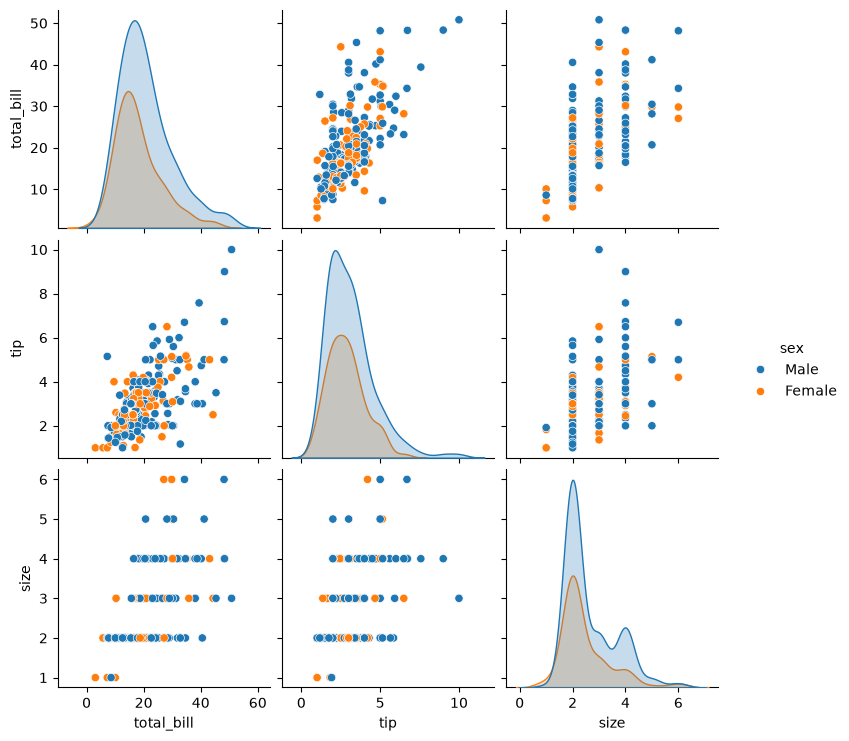

In [15]:
# Pairplot with sex as hue
sns.pairplot(df, hue='sex')
plt.show()

## Rug Plots

`sns.rugplot(df['tip'])` draws one small tick mark on the x-axis for every single value in the `tip` column, with no grouping or smoothing at all.

**Usecase:** It's usually paired with a histogram or KDE curve to double-check that the smoothed picture isn't hiding where the data points are actually bunched up or missing.

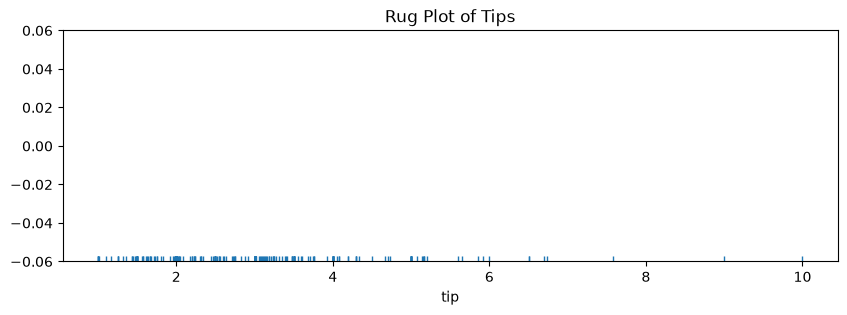

In [16]:
# Simple rug plot
plt.figure(figsize=(10, 3))
sns.rugplot(data=df, x='tip')
plt.title('Rug Plot of Tips')
plt.show()

### Combining Rug Plot with Histogram

Let's see how a rug plot looks when combined with a histogram to show both the distribution shape and the exact data points.

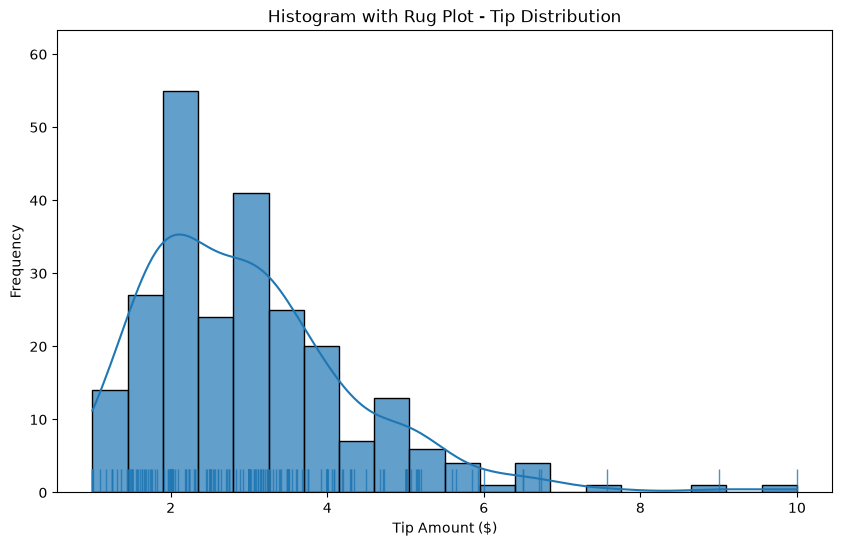

In [17]:
# Combining histogram with rug plot
plt.figure(figsize=(10, 6))
sns.histplot(df['tip'], bins=20, kde=True, alpha=0.7)
sns.rugplot(data=df, x='tip', height=0.05, alpha=0.8)
plt.title('Histogram with Rug Plot - Tip Distribution')
plt.xlabel('Tip Amount ($)')
plt.ylabel('Frequency')
plt.show()

## Summary

In this notebook, we explored various distribution plots using seaborn:

1. **Histplot**: Shows the distribution of a single variable with optional KDE curve
2. **Jointplot**: Shows the relationship between two variables with marginal distributions
   - Scatter, hex, KDE, histogram, residual, and regression variants
3. **Pairplot**: Shows relationships between all pairs of numeric variables
4. **Rugplot**: Shows the exact location of data points along an axis

These plots are essential for exploratory data analysis and understanding the underlying patterns in your data.